In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
from pathlib import Path
from textwrap import fill
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from Utils.direction_comparison import load_tc, load_rf, hd_pick, rf_pick, combine, normalize_tc, prepare_comparison, plot_comparison_heatmaps, profile_coordinates, tcRange
from Utils.plotting import LIGHT_PLOT_STYLE, plot_direction_comparison
from Utils.statistic_utils import compare_direction_angles
from Utils.tuning_curve_utils import rayleigh_test

root = Path("/mnt/senzailab/Kai/#Recording")
data_path = str(root / "{mouse}" / "{date}" / "{date}_{session}" / "data")
tc_path = data_path + "/tuning_curves/Probe{probe}/tuning_curves.tc"
rf_path = data_path + "/rfmapping/good/-100_400_1ms/Probe{probe}{suffix}/regular_unitsSpikeCounts_{date}_{session}.rfmap"

rf_range_overrides = {"m14": [-150, 150]}  # 30 bins over the measured RF span.
rf_type = "2d"  # Saved RF detections: "2d", "1d", "either", or None for all units.
rf_max_zero_bins = 2  # Skip RF units with > N zero native 1-D bins (including missing responses); None disables.
plot_options = dict(figsize=(10, 10), vmin=0, vmax=1, colorbar_label="Normalized response")
is_wrap = True


In [ ]:
recording = dict(mouse="m14", date=260609, probe="A")
fm_file_m14_260609 = tc_path.format(**recording, session=1)
rf_file_m14_260609 = rf_path.format(**recording, session=3, suffix="")

fm_m14_260609 = load_tc(fm_file_m14_260609, **recording, range=tcRange(False), label=f"m14 260609 Probe{recording['probe']} HD")
rf_m14_260609 = load_rf(rf_file_m14_260609, **recording, range=rf_range_overrides.get(recording["mouse"]), rf_type=rf_type, label=f"m14 260609 Probe{recording['probe']} RF3")

hd3_m14_260609 = hd_pick(fm_m14_260609, hd_class=3)
rf_good_m14_260609 = rf_pick(rf_m14_260609, max_zero_bins=rf_max_zero_bins)
units_m14_260609 = hd3_m14_260609.index.intersection(rf_good_m14_260609.index)
hd_normalized_m14_260609 = normalize_tc(hd3_m14_260609.loc[units_m14_260609])
rf_normalized_m14_260609 = normalize_tc(rf_good_m14_260609.loc[units_m14_260609])


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m14_260609 = prepare_comparison(hd_normalized_m14_260609, rf_normalized_m14_260609, mode="native")
plot_comparison_heatmaps(sorted_fm_m14_260609, **plot_options)
sorted_rf_m14_260609 = prepare_comparison(rf_normalized_m14_260609, hd_normalized_m14_260609, mode="native")
plot_comparison_heatmaps(sorted_rf_m14_260609, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m14_260609 = prepare_comparison(hd_normalized_m14_260609, rf_normalized_m14_260609, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m14_260609, **plot_options)
aligned_rf_m14_260609 = prepare_comparison(rf_normalized_m14_260609, hd_normalized_m14_260609, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m14_260609, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m14_260609 = prepare_comparison(hd_normalized_m14_260609, rf_normalized_m14_260609, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m14_260609, **plot_options)
# summed_rf_m14_260609 = prepare_comparison(rf_normalized_m14_260609, hd_normalized_m14_260609, mode="sum", is_wrap=is_wrap)
# plot_comparison_heatmaps(summed_rf_m14_260609, **plot_options)


In [ ]:
peaks = summed_fm_m14_260609["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m14 260609: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


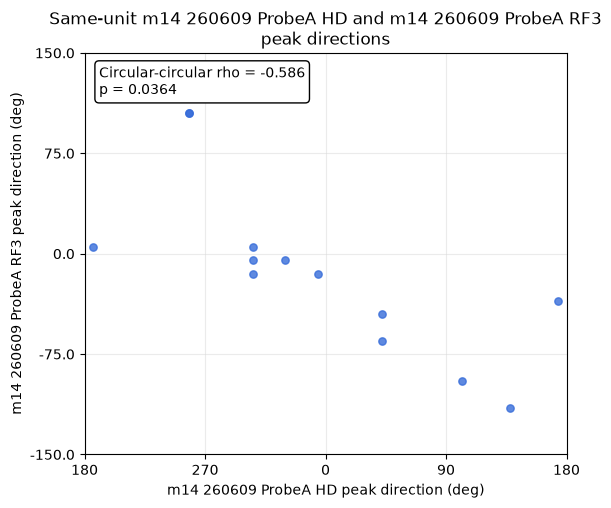

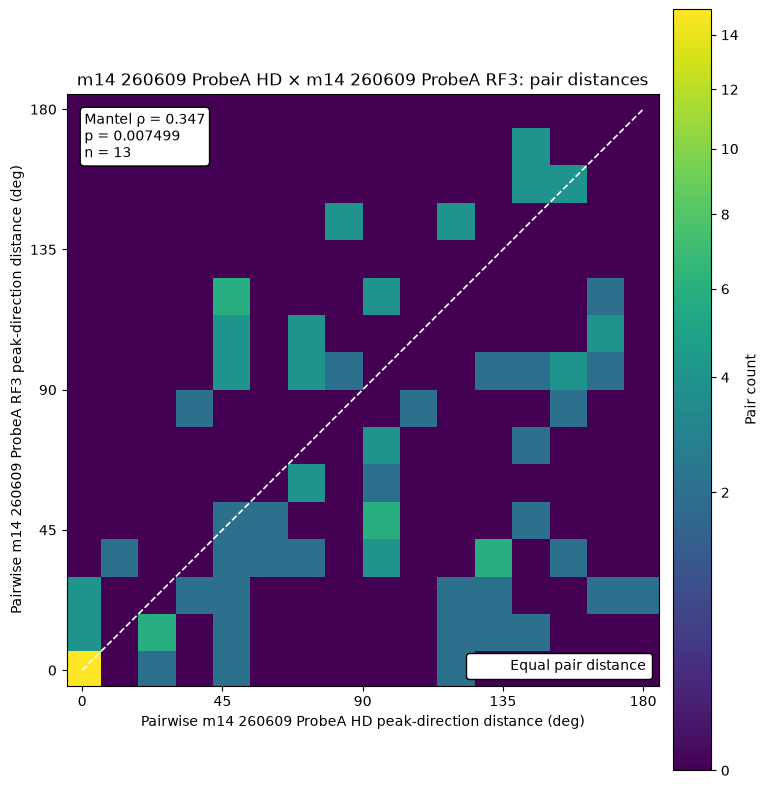

In [13]:
peaks_m14_260609 = sorted_fm_m14_260609["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m14_260609 = None
if len(peaks_m14_260609) >= 3:
    reference = peaks_m14_260609.reference_peak_deg.to_numpy()
    matched = peaks_m14_260609.matched_peak_deg.to_numpy()
    statistics_m14_260609 = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m14_260609 = plot_direction_comparison(
        reference, matched, statistics_m14_260609,
        reference_label=fm_m14_260609.attrs["label"], matched_label=rf_m14_260609.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m14_260609)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m14_260609)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m14_260609:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## m15 260630: HD 1 / RF 3

Probes **A + B**, combined with probe identity retained. HD class **2**.
RF files use the freshly regenerated `ProbeA` and `ProbeB` folders, with localization recomputed from each new RF map.


In [ ]:
recording = dict(mouse="m15", date=260630, probe="A")
fm_m15_260630_A = load_tc(tc_path.format(**recording, session=1), **recording, range=tcRange(False), label="m15 260630 ProbeA HD")
rf_m15_260630_A = load_rf(rf_path.format(**recording, session=3, suffix=""), **recording, range=rf_range_overrides.get(recording["mouse"], tcRange(True)), rf_type=rf_type, label="m15 260630 ProbeA RF3")

recording = dict(mouse="m15", date=260630, probe="B")
fm_m15_260630_B = load_tc(tc_path.format(**recording, session=1), **recording, range=tcRange(False), label="m15 260630 ProbeB HD")
rf_m15_260630_B = load_rf(rf_path.format(**recording, session=3, suffix=""), **recording, range=rf_range_overrides.get(recording["mouse"], tcRange(True)), rf_type=rf_type, label="m15 260630 ProbeB RF3")

fm_m15_260630 = combine(fm_m15_260630_A, fm_m15_260630_B, label="m15 260630 A+B HD")
rf_m15_260630 = combine(rf_m15_260630_A, rf_m15_260630_B, label="m15 260630 A+B RF3")

hd3_m15_260630 = hd_pick(fm_m15_260630, hd_class=3)
rf_good_m15_260630 = rf_pick(rf_m15_260630, max_zero_bins=rf_max_zero_bins)
units_m15_260630 = hd3_m15_260630.index.intersection(rf_good_m15_260630.index)
hd_normalized_m15_260630 = normalize_tc(hd3_m15_260630.loc[units_m15_260630])
rf_normalized_m15_260630 = normalize_tc(rf_good_m15_260630.loc[units_m15_260630])


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m15_260630 = prepare_comparison(hd_normalized_m15_260630, rf_normalized_m15_260630, mode="native")
plot_comparison_heatmaps(sorted_fm_m15_260630, **plot_options)
sorted_rf_m15_260630 = prepare_comparison(rf_normalized_m15_260630, hd_normalized_m15_260630, mode="native")
plot_comparison_heatmaps(sorted_rf_m15_260630, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m15_260630 = prepare_comparison(hd_normalized_m15_260630, rf_normalized_m15_260630, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m15_260630, **plot_options)
aligned_rf_m15_260630 = prepare_comparison(rf_normalized_m15_260630, hd_normalized_m15_260630, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m15_260630, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m15_260630 = prepare_comparison(hd_normalized_m15_260630, rf_normalized_m15_260630, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m15_260630, **plot_options)
summed_rf_m15_260630 = prepare_comparison(rf_normalized_m15_260630, hd_normalized_m15_260630, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_m15_260630, **plot_options)


In [ ]:
peaks = summed_fm_m15_260630["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m15 260630: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


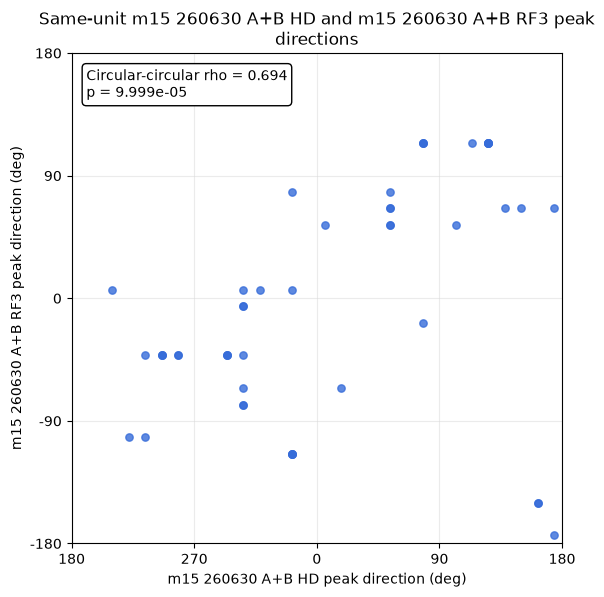

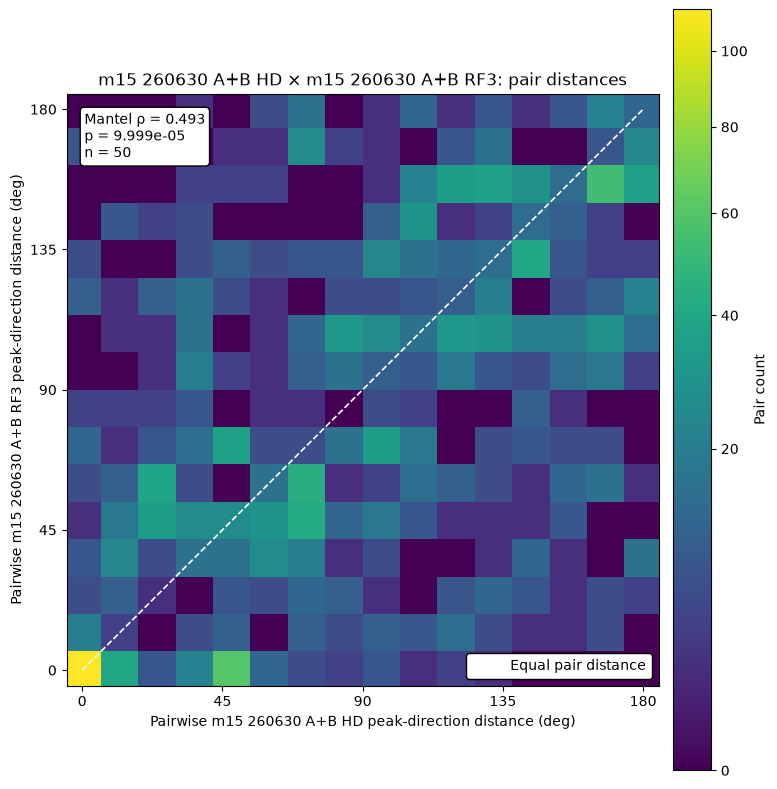

In [19]:
peaks_m15_260630 = sorted_fm_m15_260630["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m15_260630 = None
if len(peaks_m15_260630) >= 3:
    reference = peaks_m15_260630.reference_peak_deg.to_numpy()
    matched = peaks_m15_260630.matched_peak_deg.to_numpy()
    statistics_m15_260630 = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m15_260630 = plot_direction_comparison(
        reference, matched, statistics_m15_260630,
        reference_label=fm_m15_260630.attrs["label"], matched_label=rf_m15_260630.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m15_260630)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m15_260630)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m15_260630:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## m15 260630 Probe A only: HD 1 / RF 3

Use the same sessions and filters as A+B above, selecting Probe **A** only.


In [ ]:
hd3_m15_260630_A = hd_pick(fm_m15_260630_A, hd_class=3)
rf_good_m15_260630_A = rf_pick(rf_m15_260630_A, max_zero_bins=rf_max_zero_bins)
units_m15_260630_A = hd3_m15_260630_A.index.intersection(rf_good_m15_260630_A.index)
hd_normalized_m15_260630_A = normalize_tc(hd3_m15_260630_A.loc[units_m15_260630_A])
rf_normalized_m15_260630_A = normalize_tc(rf_good_m15_260630_A.loc[units_m15_260630_A])

{"HD": len(hd3_m15_260630_A), "RF": len(rf_good_m15_260630_A), "shared": len(units_m15_260630_A)}


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m15_260630_A = prepare_comparison(hd_normalized_m15_260630_A, rf_normalized_m15_260630_A, mode="native")
plot_comparison_heatmaps(sorted_fm_m15_260630_A, **plot_options)
sorted_rf_m15_260630_A = prepare_comparison(rf_normalized_m15_260630_A, hd_normalized_m15_260630_A, mode="native")
plot_comparison_heatmaps(sorted_rf_m15_260630_A, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m15_260630_A = prepare_comparison(hd_normalized_m15_260630_A, rf_normalized_m15_260630_A, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m15_260630_A, **plot_options)
aligned_rf_m15_260630_A = prepare_comparison(rf_normalized_m15_260630_A, hd_normalized_m15_260630_A, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m15_260630_A, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m15_260630_A = prepare_comparison(hd_normalized_m15_260630_A, rf_normalized_m15_260630_A, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m15_260630_A, **plot_options)
summed_rf_m15_260630_A = prepare_comparison(rf_normalized_m15_260630_A, hd_normalized_m15_260630_A, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_m15_260630_A, **plot_options)


In [ ]:
peaks = summed_fm_m15_260630_A["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m15 260630 Probe A: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


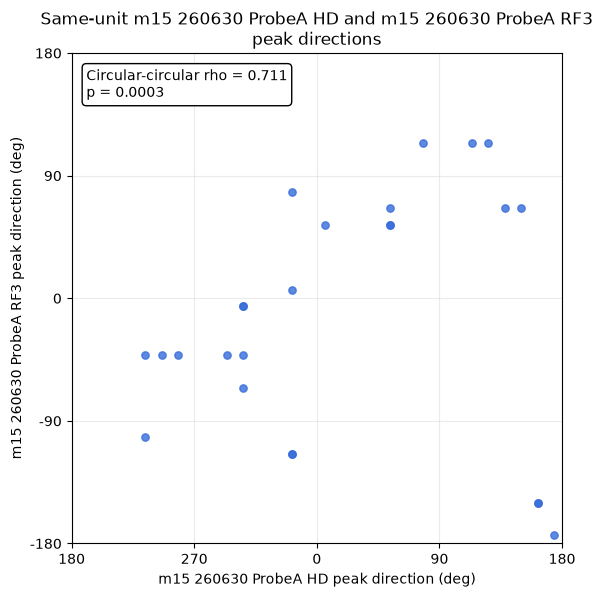

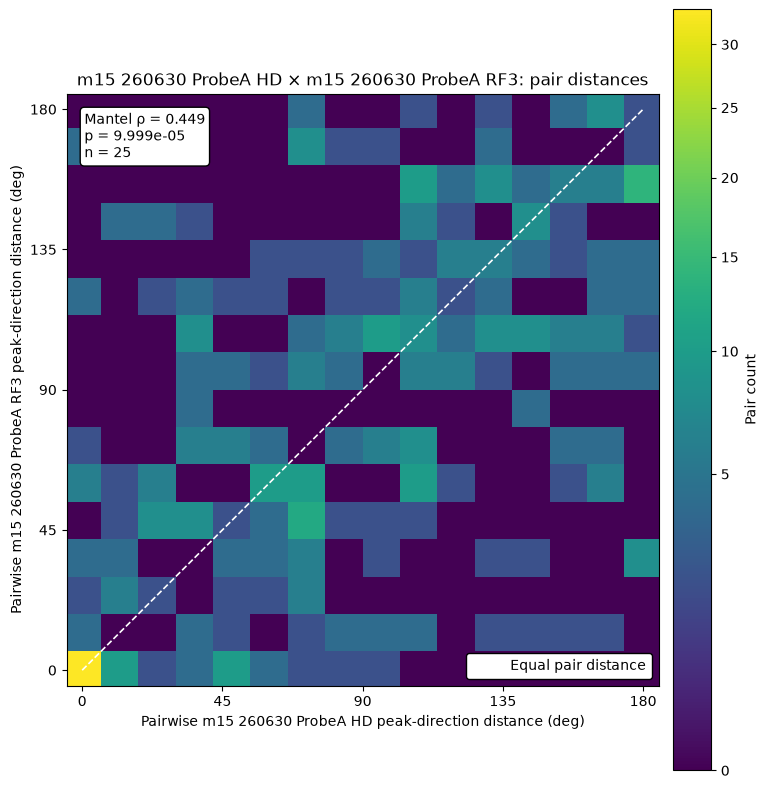

In [25]:
peaks_m15_260630_A = sorted_fm_m15_260630_A["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m15_260630_A = None
if len(peaks_m15_260630_A) >= 3:
    reference = peaks_m15_260630_A.reference_peak_deg.to_numpy()
    matched = peaks_m15_260630_A.matched_peak_deg.to_numpy()
    statistics_m15_260630_A = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m15_260630_A = plot_direction_comparison(
        reference, matched, statistics_m15_260630_A,
        reference_label=fm_m15_260630_A.attrs["label"], matched_label=rf_m15_260630_A.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m15_260630_A)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m15_260630_A)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m15_260630_A:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## m15 260630 Probe B only: HD 1 / RF 3

Use the same sessions and filters as A+B above, selecting Probe **B** only.


In [ ]:
hd3_m15_260630_B = hd_pick(fm_m15_260630_B, hd_class=3)
rf_good_m15_260630_B = rf_pick(rf_m15_260630_B, max_zero_bins=rf_max_zero_bins)
units_m15_260630_B = hd3_m15_260630_B.index.intersection(rf_good_m15_260630_B.index)
hd_normalized_m15_260630_B = normalize_tc(hd3_m15_260630_B.loc[units_m15_260630_B])
rf_normalized_m15_260630_B = normalize_tc(rf_good_m15_260630_B.loc[units_m15_260630_B])

{"HD": len(hd3_m15_260630_B), "RF": len(rf_good_m15_260630_B), "shared": len(units_m15_260630_B)}


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m15_260630_B = prepare_comparison(hd_normalized_m15_260630_B, rf_normalized_m15_260630_B, mode="native")
plot_comparison_heatmaps(sorted_fm_m15_260630_B, **plot_options)
sorted_rf_m15_260630_B = prepare_comparison(rf_normalized_m15_260630_B, hd_normalized_m15_260630_B, mode="native")
plot_comparison_heatmaps(sorted_rf_m15_260630_B, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m15_260630_B = prepare_comparison(hd_normalized_m15_260630_B, rf_normalized_m15_260630_B, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m15_260630_B, **plot_options)
aligned_rf_m15_260630_B = prepare_comparison(rf_normalized_m15_260630_B, hd_normalized_m15_260630_B, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m15_260630_B, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m15_260630_B = prepare_comparison(hd_normalized_m15_260630_B, rf_normalized_m15_260630_B, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m15_260630_B, **plot_options)
summed_rf_m15_260630_B = prepare_comparison(rf_normalized_m15_260630_B, hd_normalized_m15_260630_B, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_m15_260630_B, **plot_options)


In [ ]:
peaks = summed_fm_m15_260630_B["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m15 260630 Probe B: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


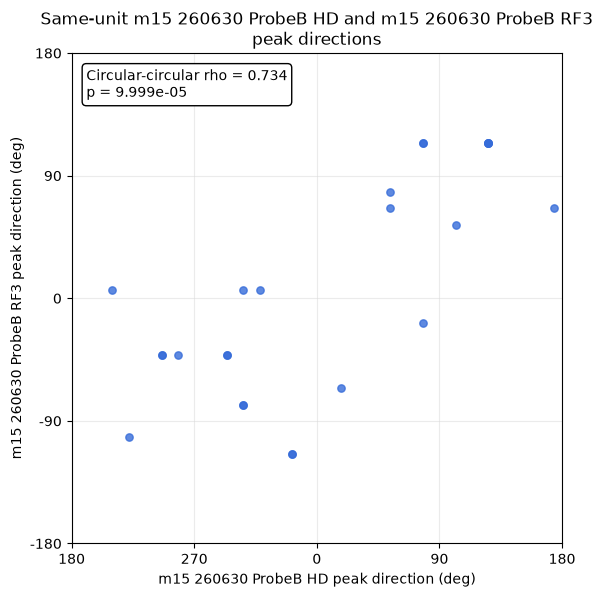

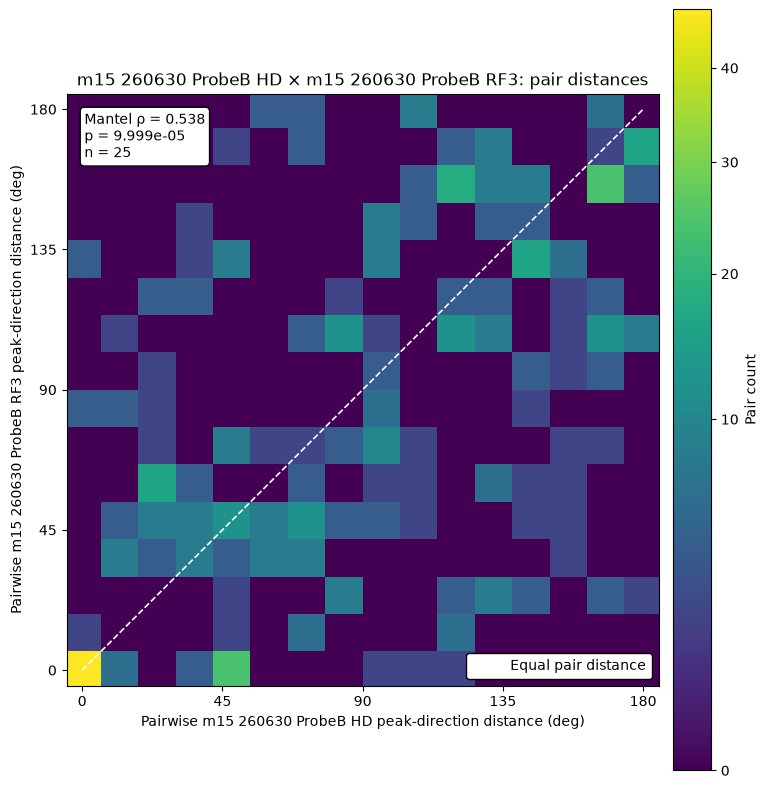

In [31]:
peaks_m15_260630_B = sorted_fm_m15_260630_B["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m15_260630_B = None
if len(peaks_m15_260630_B) >= 3:
    reference = peaks_m15_260630_B.reference_peak_deg.to_numpy()
    matched = peaks_m15_260630_B.matched_peak_deg.to_numpy()
    statistics_m15_260630_B = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m15_260630_B = plot_direction_comparison(
        reference, matched, statistics_m15_260630_B,
        reference_label=fm_m15_260630_B.attrs["label"], matched_label=rf_m15_260630_B.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m15_260630_B)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m15_260630_B)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m15_260630_B:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## m19 260827: HD 9 / RF 2

Probe **A**. HD class **2**.


In [ ]:
recording = dict(mouse="m19", date=260827, probe="A")
fm_file_m19_260827 = tc_path.format(**recording, session=9)
rf_file_m19_260827 = rf_path.format(**recording, session=2, suffix="")

fm_m19_260827 = load_tc(fm_file_m19_260827, **recording, range=tcRange(False), label=f"m19 260827 Probe{recording['probe']} HD")
rf_m19_260827 = load_rf(rf_file_m19_260827, **recording, range=rf_range_overrides.get(recording["mouse"], tcRange(True)), rf_type=rf_type, label=f"m19 260827 Probe{recording['probe']} RF2")

hd3_m19_260827 = hd_pick(fm_m19_260827, hd_class=3)
rf_good_m19_260827 = rf_pick(rf_m19_260827, max_zero_bins=rf_max_zero_bins)
units_m19_260827 = hd3_m19_260827.index.intersection(rf_good_m19_260827.index)
hd_normalized_m19_260827 = normalize_tc(hd3_m19_260827.loc[units_m19_260827])
rf_normalized_m19_260827 = normalize_tc(rf_good_m19_260827.loc[units_m19_260827])


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m19_260827 = prepare_comparison(hd_normalized_m19_260827, rf_normalized_m19_260827, mode="native")
plot_comparison_heatmaps(sorted_fm_m19_260827, **plot_options)
sorted_rf_m19_260827 = prepare_comparison(rf_normalized_m19_260827, hd_normalized_m19_260827, mode="native")
plot_comparison_heatmaps(sorted_rf_m19_260827, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m19_260827 = prepare_comparison(hd_normalized_m19_260827, rf_normalized_m19_260827, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m19_260827, **plot_options)
aligned_rf_m19_260827 = prepare_comparison(rf_normalized_m19_260827, hd_normalized_m19_260827, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m19_260827, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m19_260827 = prepare_comparison(hd_normalized_m19_260827, rf_normalized_m19_260827, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m19_260827, **plot_options)
summed_rf_m19_260827 = prepare_comparison(rf_normalized_m19_260827, hd_normalized_m19_260827, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_m19_260827, **plot_options)


In [ ]:
peaks = summed_fm_m19_260827["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m19 260827: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


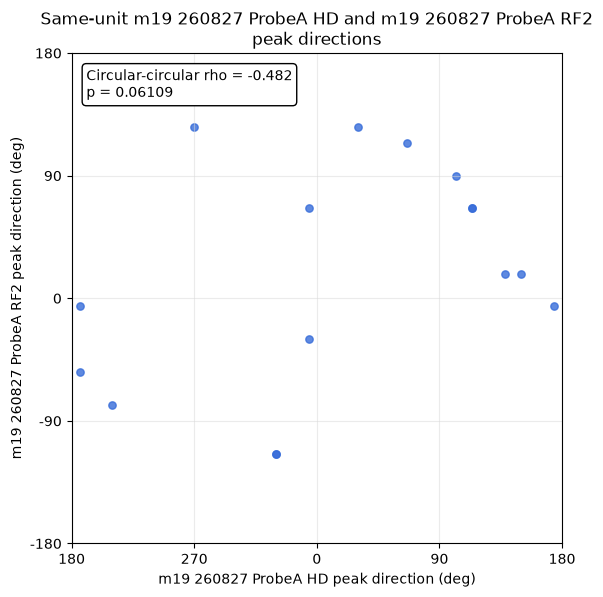

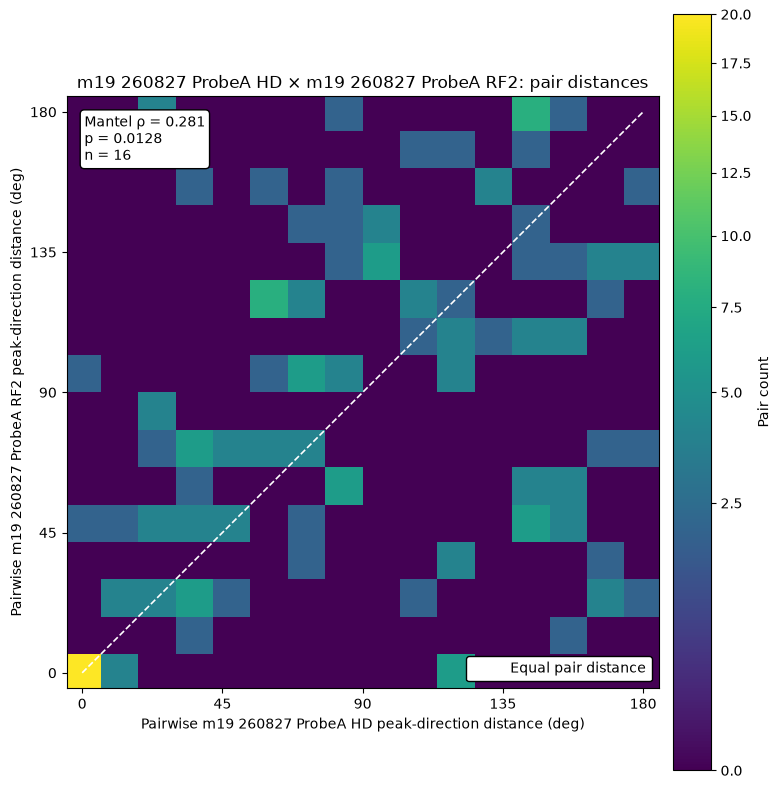

In [37]:
peaks_m19_260827 = sorted_fm_m19_260827["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m19_260827 = None
if len(peaks_m19_260827) >= 3:
    reference = peaks_m19_260827.reference_peak_deg.to_numpy()
    matched = peaks_m19_260827.matched_peak_deg.to_numpy()
    statistics_m19_260827 = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m19_260827 = plot_direction_comparison(
        reference, matched, statistics_m19_260827,
        reference_label=fm_m19_260827.attrs["label"], matched_label=rf_m19_260827.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m19_260827)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m19_260827)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m19_260827:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## m20 260921: HD 9 / RF 2

Probe **A**. HD class **2**.


In [ ]:
recording = dict(mouse="m20", date=260921, probe="A")
fm_file_m20_260921 = tc_path.format(**recording, session=9)
rf_file_m20_260921 = rf_path.format(**recording, session=2, suffix="")

fm_m20_260921 = load_tc(fm_file_m20_260921, **recording, range=tcRange(False), label=f"m20 260921 Probe{recording['probe']} HD")
rf_m20_260921 = load_rf(rf_file_m20_260921, **recording, range=rf_range_overrides.get(recording["mouse"], tcRange(True)), rf_type=rf_type, label=f"m20 260921 Probe{recording['probe']} RF2")

hd3_m20_260921 = hd_pick(fm_m20_260921, hd_class=3)
rf_good_m20_260921 = rf_pick(rf_m20_260921, max_zero_bins=rf_max_zero_bins)
units_m20_260921 = hd3_m20_260921.index.intersection(rf_good_m20_260921.index)
hd_normalized_m20_260921 = normalize_tc(hd3_m20_260921.loc[units_m20_260921])
rf_normalized_m20_260921 = normalize_tc(rf_good_m20_260921.loc[units_m20_260921])


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_m20_260921 = prepare_comparison(hd_normalized_m20_260921, rf_normalized_m20_260921, mode="native")
plot_comparison_heatmaps(sorted_fm_m20_260921, **plot_options)
sorted_rf_m20_260921 = prepare_comparison(rf_normalized_m20_260921, hd_normalized_m20_260921, mode="native")
plot_comparison_heatmaps(sorted_rf_m20_260921, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_m20_260921 = prepare_comparison(hd_normalized_m20_260921, rf_normalized_m20_260921, mode="aligned")
plot_comparison_heatmaps(aligned_fm_m20_260921, **plot_options)
aligned_rf_m20_260921 = prepare_comparison(rf_normalized_m20_260921, hd_normalized_m20_260921, mode="aligned")
plot_comparison_heatmaps(aligned_rf_m20_260921, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_m20_260921 = prepare_comparison(hd_normalized_m20_260921, rf_normalized_m20_260921, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_m20_260921, **plot_options)
summed_rf_m20_260921 = prepare_comparison(rf_normalized_m20_260921, hd_normalized_m20_260921, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_m20_260921, **plot_options)


In [ ]:
peaks = summed_fm_m20_260921["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "m20 260921: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


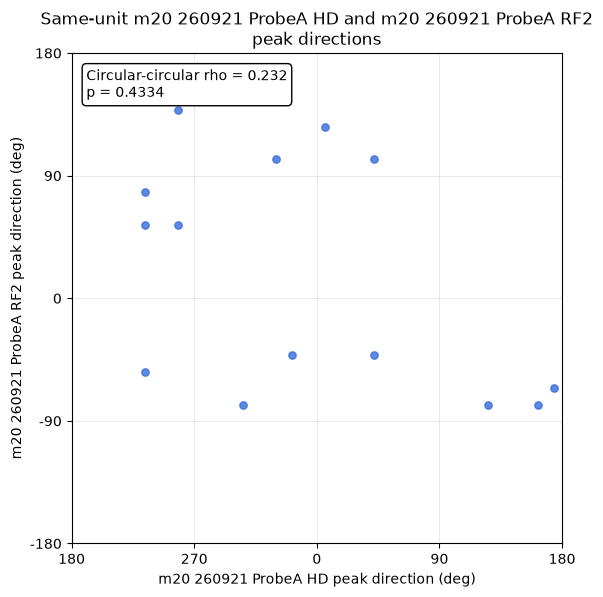

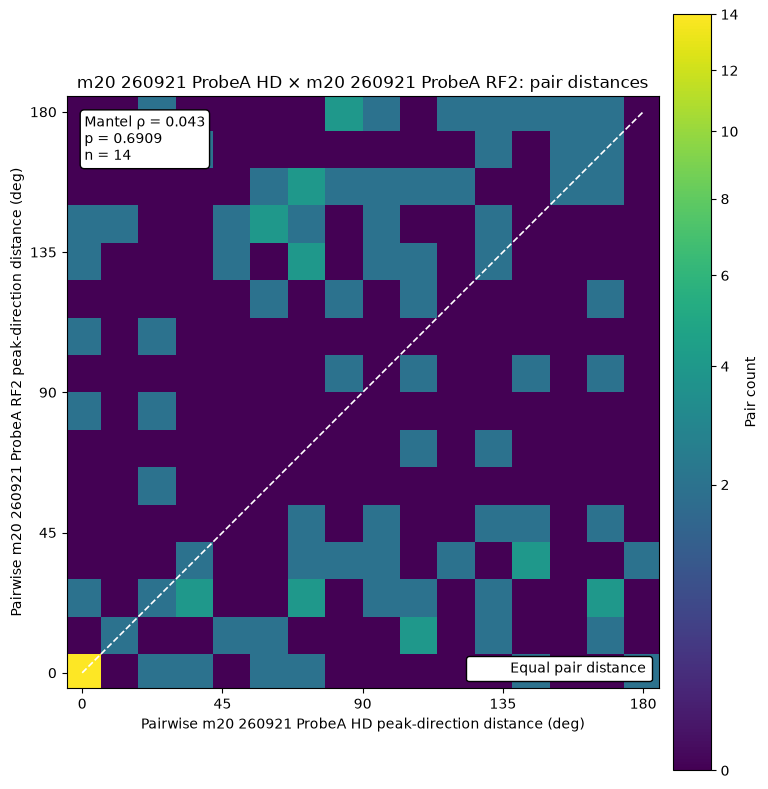

In [43]:
peaks_m20_260921 = sorted_fm_m20_260921["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_m20_260921 = None
if len(peaks_m20_260921) >= 3:
    reference = peaks_m20_260921.reference_peak_deg.to_numpy()
    matched = peaks_m20_260921.matched_peak_deg.to_numpy()
    statistics_m20_260921 = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_m20_260921 = plot_direction_comparison(
        reference, matched, statistics_m20_260921,
        reference_label=fm_m20_260921.attrs["label"], matched_label=rf_m20_260921.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_m20_260921)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_m20_260921)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_m20_260921:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)


## All four mice: m14 + m15 + m19 + m20

Pool the mouse-level tables loaded with `rf_type` above, including both m15 probes, then apply the
same HD2 and RF missing/zero-bin limits and select their shared units explicitly.
Rows are stacked without averaging; `(mouse, date, probe, unit_id)` remains unique.


In [ ]:
fm_all = combine(fm_m14_260609, fm_m15_260630, fm_m19_260827, fm_m20_260921, label="All mice HD")
# Pool on a common full-circle grid; m14 bins outside ﷿﷿150﷿﷿ stay unmeasured.
rf_all = combine(rf_m14_260609, rf_m15_260630, rf_m19_260827, rf_m20_260921, range=tcRange(True), label="All mice RF")

hd3_all = hd_pick(fm_all, hd_class=3)
rf_good_all = rf_pick(rf_all, max_zero_bins=rf_max_zero_bins)
units_all = hd3_all.index.intersection(rf_good_all.index)
hd_normalized_all = normalize_tc(hd3_all.loc[units_all])
rf_normalized_all = normalize_tc(rf_good_all.loc[units_all])


In [ ]:
# Native angles, one explicitly selected reference per call.
sorted_fm_all = prepare_comparison(hd_normalized_all, rf_normalized_all, mode="native")
plot_comparison_heatmaps(sorted_fm_all, **plot_options)
sorted_rf_all = prepare_comparison(rf_normalized_all, hd_normalized_all, mode="native")
plot_comparison_heatmaps(sorted_rf_all, **plot_options)


In [ ]:
# Subtract the reference peak from both curves.
aligned_fm_all = prepare_comparison(hd_normalized_all, rf_normalized_all, mode="aligned")
plot_comparison_heatmaps(aligned_fm_all, **plot_options)
aligned_rf_all = prepare_comparison(rf_normalized_all, hd_normalized_all, mode="aligned")
plot_comparison_heatmaps(aligned_rf_all, **plot_options)


In [ ]:
# Center the reference; add its peak to the matched curve.
summed_fm_all = prepare_comparison(hd_normalized_all, rf_normalized_all, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_fm_all, **plot_options)
summed_rf_all = prepare_comparison(rf_normalized_all, hd_normalized_all, mode="sum", is_wrap=is_wrap)
plot_comparison_heatmaps(summed_rf_all, **plot_options)


In [ ]:
peaks = summed_fm_all["peaks"]
peak_sum_deg = (peaks["reference_peak_deg"] + peaks["matched_peak_deg"]) % 360
peak_sum_rad = np.deg2rad(peak_sum_deg.dropna().to_numpy())

counts, edges = np.histogram(peak_sum_rad, bins=30, range=(0, 2 * np.pi))
centers_deg = np.rad2deg((edges[:-1] + edges[1:]) / 2)
# Equal occupancy defines a uniform null; retain all bins, including zeros.
rayleigh_score, rayleigh_p = rayleigh_test(counts, np.ones_like(counts), centers_deg)

with plt.rc_context(LIGHT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"}, layout="constrained")
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=np.diff(edges), edgecolor="white")
    ax.set_theta_zero_location("N")

    ax.set_theta_direction(-1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Unit count (radial axis)")
    ax.set_title(
        "All mice: HD + RF peak angles\n"
        f"n = {int(counts.sum())}\n"
        f"Rayleigh score = {rayleigh_score:.3f}, p = {rayleigh_p:.3g}",
        pad=20,
    )
    plt.show()


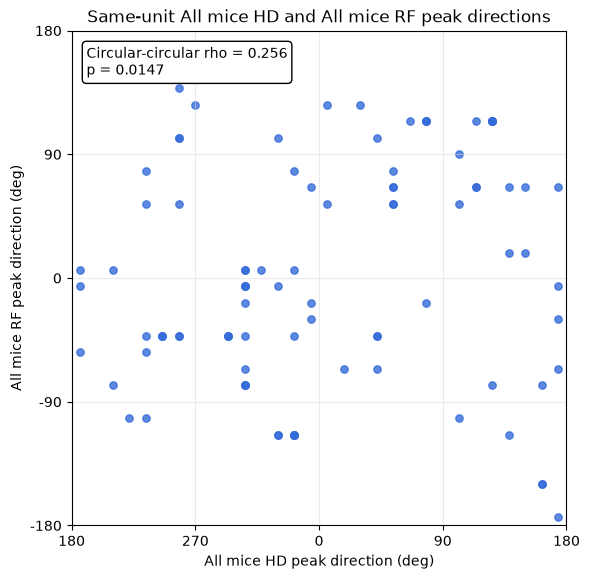

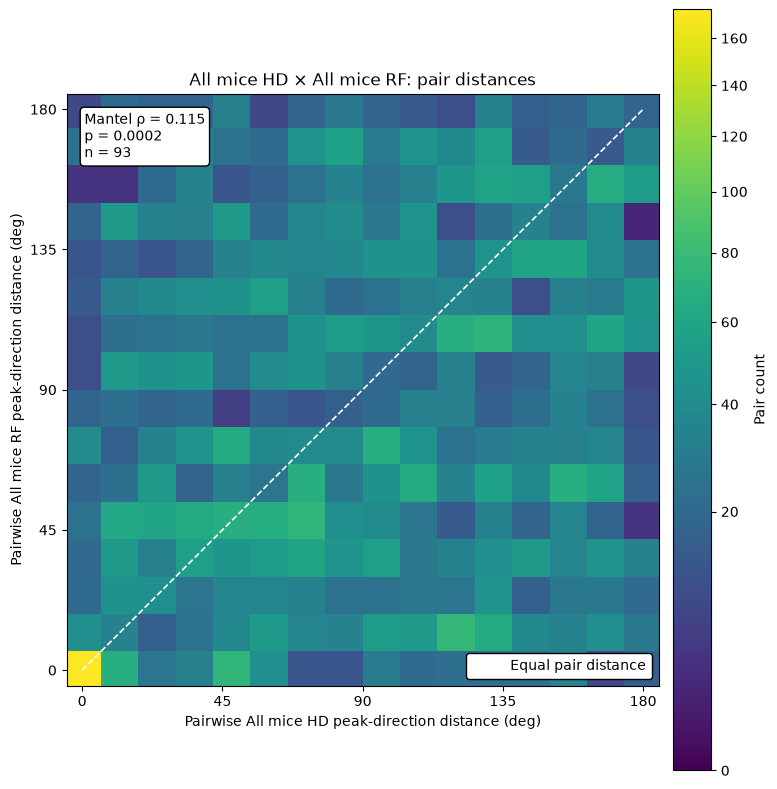

In [49]:
peaks_all = sorted_fm_all["peaks"].dropna(subset=["reference_peak_deg", "matched_peak_deg"])
statistics_all = None
if len(peaks_all) >= 3:
    reference = peaks_all.reference_peak_deg.to_numpy()
    matched = peaks_all.matched_peak_deg.to_numpy()
    statistics_all = compare_direction_angles(reference, matched, n_permutations=10_000, random_seed=1)
    statistics_figures_all = plot_direction_comparison(
        reference, matched, statistics_all,
        reference_label=fm_all.attrs["label"], matched_label=rf_all.attrs["label"],
        reference_ticklabels=profile_coordinates(fm_all)["ticklabels"],
        matched_ticklabels=profile_coordinates(rf_all)["ticklabels"],
        show=False,
    )
    for figure, axis in statistics_figures_all:
        axis.set_title(fill(axis.get_title(), width=60))
        figure.tight_layout()
        display(figure)
        plt.close(figure)
